# POSE — `setup.ipynb` : von CAD zu Modellen

Diese Notebook baut **aus den CAD-Teilen die Modelle**, die `infer.ipynb` /
`e2e_infer.py` zur 6D-Pose-Schätzung brauchen. Alles ist **inline** dokumentiert
— keine versteckten Imports auf Projektmodule, damit man das Notebook jemand
anderem in die Hand geben kann und es selbsterklärend ist.

**Pipeline (eine Stufe pro Abschnitt, mit Visualisierung danach):**

| Stufe | Was passiert | Wo läuft es | Output |
|---|---|---|---|
| 0 · Config | `.env` laden, Teile auto-discovern, GPU-Box-Helper | lokal | — |
| 1 · Daten-Gen | Isaac-SDG: Teil fallen lassen, Top-Down RGB+Tiefe+Maske+Pose | **GPU-Box** | `training_data/faceset_<part>/` |
| 2 · Face-Discovery | Settle-Posen clustern (g_body + rot_match) -> Faces + Registry | lokal/Box | `models/registry/<part>/` |
| 3 · Snippets | gelabelte deskewte Crops + train/val-Manifest | lokal/Box | `training_data/snippets/<part>/` |
| 4 · Training (Face) | kleines CNN pro Teil (Face-Classifier) | **GPU-Box** (torch) | `models/<part>.pt` |
| 5 · Detektor (OBB) | Multi-Part-Szenen -> YOLOv8-OBB-Dataset + Training | **GPU-Box** (ultralytics) | `models/detector.pt` |

**Konvention (durchgehend):** Z-up Welt, Rotation `world = R @ body` (Spalten-
konvention), Ursprung = Tisch-Nullpunkt. Diese Konvention ist im pose_result-
Contract eingefroren und wird hier nie transponiert.

> **GPU-Stufen:** Daten-Generierung (Isaac Sim) und Training (torch/ultralytics)
> laufen auf Max' GPU-Workstation. Die Helper unten (`wake_box`, `on_box`, `push`,
> `pull`) kapseln SSH/rsync. Stufen 2+3 (numpy/scipy/PIL) laufen auch lokal.


## 0 · Config — `.env`, Teile-Discovery, GPU-Box-Helper

`project/.env` liefert Box-Adresse + Pfade. Die Teile werden direkt aus
`project/cad_input/enviroment/parts/*.usd` entdeckt — neues Teil reinlegen,
Notebook neu laufen lassen, fertig. Die Box-Helper sind dünne SSH/rsync-Wrapper.


In [1]:
import os, sys, json, subprocess, pathlib

# ── Pfade (Notebook-CWD-unabhängig: relativ zu project/) ─────────────────────
PROJECT = pathlib.Path.cwd()
if PROJECT.name != "project":                       # erlaubt Start aus Repo-Root
    cand = PROJECT / "project"
    PROJECT = cand if cand.is_dir() else PROJECT
CAD_PARTS   = PROJECT / "cad_input" / "enviroment" / "parts"
TRAIN_DATA  = PROJECT / "training_data"
MODELS      = PROJECT / "models"
REGISTRY    = MODELS / "registry"
TEMP        = PROJECT / "temp"
for d in (TRAIN_DATA, MODELS, REGISTRY, TEMP):
    d.mkdir(parents=True, exist_ok=True)

# ── .env laden (kein dotenv-Dep: simpler Parser) ─────────────────────────────
def load_env(path):
    env = {}
    if path.exists():
        for line in path.read_text().splitlines():
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                k, v = line.split("=", 1)
                env[k.strip()] = v.strip()
    return env

ENV = load_env(PROJECT / ".env")
GPU_HOST      = ENV.get("GPU_HOST", "max@100.85.216.95")
WOL_HOST      = ENV.get("WOL_HOST", "admin@100.117.146.46")
WOL_MAC       = ENV.get("WOL_MAC", "24:4b:fe:4b:79:e0")
BOX_REPO      = ENV.get("BOX_REPO", "/mnt/data/kip_pose")
BOX_ISAAC_PY  = ENV.get("BOX_ISAAC_PY", "/mnt/data/isaacsim-venv/bin/python")
BOX_FACES_PY  = ENV.get("BOX_FACES_PY", "/mnt/data/faces-venv/bin/python")
BOX_TRAIN_PY  = ENV.get("BOX_TRAIN_PY", "/mnt/data/train-venv/bin/python")

# ── Teile aus dem CAD-Ordner discovern ───────────────────────────────────────
def discover_parts():
    """Alle <part>.usd in cad_input/.../parts/ -> sortierte Namensliste."""
    if not CAD_PARTS.is_dir():
        return []
    return sorted(p.stem for p in CAD_PARTS.glob("*.usd"))

PARTS = discover_parts()
print("Teile entdeckt:", PARTS)
print("GPU-Box:", GPU_HOST, "| Box-Repo:", BOX_REPO)


Teile entdeckt: ['Anker_Kurz', 'Anker_Lang', 'Buerstenhalter_2polig', 'Poltopf_kurz_centered']
GPU-Box: max@100.85.216.95 | Box-Repo: /mnt/data/kip_pose


In [2]:
# ── GPU-Box-Helper: wake / status / remote-exec / rsync ──────────────────────
def box_up(timeout=8):
    """True, wenn die Box per SSH erreichbar ist."""
    r = subprocess.run(["ssh", "-o", f"ConnectTimeout={timeout}", "-o", "BatchMode=yes",
                        GPU_HOST, "echo ok"], capture_output=True, text=True)
    return r.returncode == 0 and "ok" in r.stdout

def wake_box(wait=60):
    """Wake-on-LAN via den Always-on-Pi, dann auf SSH warten (~45s Boot)."""
    if box_up():
        print("Box ist schon wach."); return True
    print(f"Box schläft -> WoL {WOL_MAC} über {WOL_HOST} ...")
    subprocess.run(["ssh", WOL_HOST, f"wakeonlan {WOL_MAC}"], capture_output=True, text=True)
    import time
    for _ in range(wait):
        time.sleep(2)
        if box_up():
            print("Box ist wach."); return True
    print("Box kam nicht hoch (Timeout)."); return False

def on_box(cmd, py=None, check=True, capture=False):
    """Befehl auf der Box ausführen. ``py`` -> ein Python-Interpreter-Pfad."""
    full = f"{py} {cmd}" if py else cmd
    full = f"cd {BOX_REPO} && {full}"
    r = subprocess.run(["ssh", GPU_HOST, full],
                       text=True, capture_output=capture)
    if check and r.returncode != 0:
        raise RuntimeError(f"on_box failed ({r.returncode}): {full}")
    return r.stdout if capture else r.returncode

def push(local, remote):
    """rsync local -> Box:remote (Verzeichnis oder Datei)."""
    subprocess.run(["rsync", "-az", "--mkpath", str(local), f"{GPU_HOST}:{remote}"], check=True)

def pull(remote, local):
    """rsync Box:remote -> local."""
    pathlib.Path(local).parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["rsync", "-az", f"{GPU_HOST}:{remote}", str(local)], check=True)

print("Box-Helper bereit. Box erreichbar?", box_up())


Box-Helper bereit. Box erreichbar? True


## 1 · Daten-Generierung — Isaac-SDG pro Teil (GPU-Box)

**Marc's Isaac-Render-Skript ist die Foundation.** Pro Teil:

1. Teil mit zufälliger SO(3)-Orientierung aus Höhe **fallen lassen** (Physik:
   Gravitation + Boden-Collider), settlen lassen.
2. Den **Top-Down-Render** direkt nach dem Settle aufnehmen: RGB +
   `distance_to_camera` (Tiefe) + `semantic_segmentation` (Maske).
3. Die gesettelte 6D-Rotation `R` (Spaltenkonvention `world = R @ body`) und die
   Gravitationsrichtung im Body-Frame `g_body` aufzeichnen.

N-mal wiederholt ergibt das den **Faceset**: `manifest.jsonl` (eine Zeile pro
Drop: `i, rgb, dep, msk, R, g_body`) + die `rgb_/dep_/msk_`-Dateien. Das ist die
Grundlage für Face-Discovery (Stufe 2) und das Snippet-Dataset (Stufe 3).

Das Render-Skript wird als **String-Cell** auf die Box geschrieben und dort mit
dem Isaac-venv ausgeführt — kein zusätzliches Repo-File nötig. Es entspricht
1:1 Marc's `render_dataset.py`-Logik.

> Die Facesets (RGB+Tiefe+Maske, viele MB) bleiben auf der Box und werden NICHT
> komplett heruntergeladen — nur Beispiel-Renders zum Visualisieren. Stufen 2-4
> laufen direkt auf der Box gegen die Facesets.


In [3]:
# ── Isaac-SDG-Renderer: inline als String, auf die Box geschrieben ───────────
# Entspricht Marc's sim_code/render_dataset.py (Foundation). Drop -> settle ->
# Top-Down RGB+Tiefe+Maske + gesettelte Rotation. Auf der Box mit dem Isaac-venv
# laufen lassen. Pro Teil EIN faceset_<part>/.
RENDER_DATASET_SRC = r"""
import argparse, json, os, time, sys
import numpy as np
def log(m): print(f"[ds {time.strftime('%T')}] {m}", flush=True)
def main():
    p = argparse.ArgumentParser()
    p.add_argument("--part", required=True); p.add_argument("--out", required=True)
    p.add_argument("--num", type=int, default=160); p.add_argument("--scale", type=float, default=0.001)
    p.add_argument("--cam-h", type=float, default=0.16); p.add_argument("--focal", type=float, default=24.0)
    p.add_argument("--drop-h", type=float, default=0.16); p.add_argument("--settle", type=int, default=160)
    p.add_argument("--res", type=int, default=900); p.add_argument("--pad", type=float, default=0.10)
    p.add_argument("--seed", type=int, default=42)
    a = p.parse_args(); os.environ["OMNI_KIT_ACCEPT_EULA"] = "YES"; os.makedirs(a.out, exist_ok=True)
    log(f"booting SimulationApp (N={a.num}) ..."); from isaacsim import SimulationApp
    app = SimulationApp({"headless": True})
    import omni.usd, omni.replicator.core as rep, omni.timeline, carb
    from pxr import Usd, UsdGeom, UsdLux, UsdPhysics, Gf
    from PIL import Image
    s = carb.settings.get_settings(); s.set("/app/asyncRendering", False); s.set("/omni/replicator/asyncRendering", False)
    sys.path.insert(0, os.path.join(os.environ.get("BOX_REPO","/mnt/data/kip_pose"), "sim_code"))
    import datagenerationscript as dg
    omni.usd.get_context().new_stage(); stage = omni.usd.get_context().get_stage()
    UsdGeom.SetStageUpAxis(stage, UsdGeom.Tokens.z); UsdGeom.SetStageMetersPerUnit(stage, 1.0)
    UsdGeom.Xform.Define(stage, "/World")
    ground = UsdGeom.Mesh.Define(stage, "/World/Ground"); g = 1.0
    ground.CreatePointsAttr([(-g,-g,0),(g,-g,0),(g,g,0),(-g,g,0)])
    ground.CreateFaceVertexCountsAttr([4]); ground.CreateFaceVertexIndicesAttr([0,1,2,3]); ground.CreateNormalsAttr([(0,0,1)]*4)
    coll = UsdGeom.Cube.Define(stage, "/World/_Ground"); coll.GetSizeAttr().Set(1.0)
    cx = UsdGeom.Xformable(coll); cx.ClearXformOpOrder(); cx.AddTranslateOp().Set(Gf.Vec3d(0,0,-0.5)); cx.AddScaleOp().Set(Gf.Vec3f(8,8,1))
    UsdPhysics.CollisionAPI.Apply(coll.GetPrim()); UsdGeom.Imageable(coll.GetPrim()).MakeInvisible()
    ps = UsdPhysics.Scene.Define(stage, "/World/_Phys"); ps.CreateGravityDirectionAttr(Gf.Vec3f(0,0,-1)); ps.CreateGravityMagnitudeAttr(9.81)
    UsdLux.DomeLight.Define(stage, "/World/DomeLight").CreateIntensityAttr(1000.0)
    cam = UsdGeom.Camera.Define(stage, "/World/TopCam"); cam.AddTranslateOp().Set(Gf.Vec3d(0,0,a.cam_h))
    cam.CreateFocalLengthAttr(a.focal); cam.CreateClippingRangeAttr(Gf.Vec2f(0.001,100.0))
    for _ in range(20): app.update()
    rp = rep.create.render_product("/World/TopCam", (a.res, a.res))
    a_rgb = rep.AnnotatorRegistry.get_annotator("rgb"); a_dep = rep.AnnotatorRegistry.get_annotator("distance_to_camera")
    a_sem = rep.AnnotatorRegistry.get_annotator("semantic_segmentation")
    for an in (a_rgb,a_dep,a_sem): an.attach([rp])
    timeline = omni.timeline.get_timeline_interface(); rng = np.random.default_rng(a.seed)
    down = np.array([0.0,0.0,-1.0]); manifest = []
    for i in range(a.num):
        for prim in list(stage.Traverse()):
            if prim.GetPath().pathString.startswith("/World/Obj"): stage.RemovePrim(prim.GetPath())
        prim = stage.DefinePrim("/World/Obj", "Xform"); xf = UsdGeom.Xformable(prim); xf.ClearXformOpOrder()
        x = float(rng.uniform(-0.015,0.015)); y = float(rng.uniform(-0.015,0.015))
        xf.AddTranslateOp().Set(Gf.Vec3d(x,y,a.drop_h))
        rx,ry,rz = (float(rng.uniform(0,360)) for _ in range(3))
        xf.AddOrientOp().Set(dg.euler_to_quaternion(rx,ry,rz)); xf.AddScaleOp().Set(Gf.Vec3f(a.scale,a.scale,a.scale))
        prim.GetReferences().AddReference(a.part); dg.add_update_semantics(prim, "part")
        dg.apply_rigid_body(prim); dg.apply_collision(prim, stage)
        for _ in range(10): app.update()
        timeline.play()
        for _ in range(a.settle): app.update()
        timeline.pause()
        for _ in range(5): app.update()
        rep.orchestrator.step(rt_subframes=16)
        rgb = np.asarray(a_rgb.get_data())[:,:,:3]; dep = np.asarray(a_dep.get_data())
        sem = a_sem.get_data(); sdata = np.asarray(sem["data"]) if isinstance(sem,dict) else np.asarray(sem)
        if sdata.ndim > 2: sdata = sdata[...,0]
        mask = sdata != 0
        if mask.sum() < 200: log(f"{i}: empty mask, skip"); continue
        ys,xs = np.nonzero(mask); H,W = mask.shape
        pw,ph = xs.max()-xs.min(), ys.max()-ys.min(); px,py = int(pw*a.pad)+2, int(ph*a.pad)+2
        x0,x1 = max(0,xs.min()-px), min(W,xs.max()+px); y0,y1 = max(0,ys.min()-py), min(H,ys.max()+py)
        M = np.array(UsdGeom.Xformable(prim).ComputeLocalToWorldTransform(Usd.TimeCode.Default()), dtype=float).reshape(4,4)
        rows = M[:3,:3]; rows = rows/np.linalg.norm(rows,axis=1,keepdims=True); R = rows.T; g_body = (R.T @ down)
        Image.fromarray(rgb[y0:y1,x0:x1]).save(os.path.join(a.out, f"rgb_{i:04d}.png"))
        np.save(os.path.join(a.out, f"dep_{i:04d}.npy"), dep[y0:y1,x0:x1].astype(np.float32))
        np.save(os.path.join(a.out, f"msk_{i:04d}.npy"), mask[y0:y1,x0:x1])
        manifest.append({"i":i,"rgb":f"rgb_{i:04d}.png","dep":f"dep_{i:04d}.npy","msk":f"msk_{i:04d}.npy",
                         "R":R.flatten().round(6).tolist(),"g_body":g_body.round(6).tolist()})
        if i % 20 == 0: log(f"{i}/{a.num}")
    with open(os.path.join(a.out, "manifest.jsonl"), "w") as f:
        for m in manifest: f.write(json.dumps(m)+"\n")
    log(f"done -> {a.out} ({len(manifest)} crops)"); app.close()
if __name__ == "__main__": main()
"""
print(f"Render-Skript: {len(RENDER_DATASET_SRC)} Zeichen — wird auf die Box geschrieben.")


Render-Skript: 5625 Zeichen — wird auf die Box geschrieben.


In [4]:
# ── Faceset pro Teil auf der Box rendern ─────────────────────────────────────
# ACHTUNG: braucht eine laufende GPU-Box + Isaac-venv. Pro Teil ~5-10 min.
# Die Teile-USDs müssen unter BOX_REPO/data/SDG/IsaacSim/USD-Files/<part>.usd
# liegen (auf der Box bereits vorhanden). Schon gerenderte Facesets werden NICHT
# neu erzeugt — Re-run ist günstig.
def render_faceset(part, num=160, force=False):
    """Rendert faceset_<part>/ auf der Box. No-op wenn schon vorhanden (außer force)."""
    box_out = f"{BOX_REPO}/data/output/faceset_{part}"
    exists = on_box(f"test -f {box_out}/manifest.jsonl", check=False) == 0
    if exists and not force:
        n = on_box(f"wc -l < {box_out}/manifest.jsonl", capture=True).strip()
        print(f"[render] faceset_{part} existiert schon ({n} Drops) — skip (force=True zum Neu-Rendern).")
        return box_out
    # Render-Skript auf die Box schreiben
    on_box(f"mkdir -p {BOX_REPO}/temp")
    subprocess.run(["ssh", GPU_HOST, f"cat > {BOX_REPO}/temp/_render_dataset.py"],
                   input=RENDER_DATASET_SRC, text=True, check=True)
    part_usd = f"{BOX_REPO}/data/SDG/IsaacSim/USD-Files/{part}.usd"
    print(f"[render] faceset_{part}: {num} Drops (Isaac, headless) ... das dauert.")
    on_box(f"BOX_REPO={BOX_REPO} {BOX_ISAAC_PY} -u temp/_render_dataset.py "
           f"--part {part_usd} --out {box_out} --num {num}", check=True)
    return box_out

# Beispiel-Aufruf (auskommentiert — nur wenn wirklich neu gerendert werden soll):
# for part in PARTS:
#     render_faceset(part, num=160)

# Status der vorhandenen Facesets auf der Box:
if box_up():
    listing = on_box("ls data/output/ 2>/dev/null | grep faceset_ || true", capture=True)
    print("Facesets auf der Box:\n" + (listing or "  (keine)"))
else:
    print("Box nicht erreichbar — wake_box() ausführen, dann render_faceset(part).")


Facesets auf der Box:
faceset_Anker_Kurz
faceset_Anker_Lang
faceset_Buerstenhalter_2polig
faceset_Getriebegehaeuse_typ4
faceset_Poltopf_kurz_centered
faceset_Zahnrad



### Multi-Part-Szenen für den OBB-Detektor — DR + alle Klassen (GPU-Box)

Der **Detektor** (Stufe 5) braucht *Szenen* mit **mehreren Teilen pro Bild** in
der echten Zelle (Tisch + Roboter + Tray), nicht Einzel-Teil-Facesets. Diese
Stufe rendert genau das: `gen_dataset.py` öffnet die Zellen-Szene (`GST_Scene.usd`),
lässt **6–14 Teile aus allen Klassen** (Anker_Kurz/Anker_Lang/Poltopf/Bürstenhalter/
Getriebe/Zahnrad) per Physik fallen + settlen, und schreibt pro Szene
`rgb_<idx>.png` + `obb_2d_<idx>.json` (orientierte Boxen via PCA auf den
Instanz-Masken, occlusion-getaggt).

**Domain-Randomization pro Szene:** Dome-Light-Intensität + Farbe, ein bewegtes
Distant-Light, Kamera-Eye/Look-Jitter + variable Brennweite, variable Teilezahl.
So lernt der Detektor robuste Features statt einer einzigen Beleuchtung.

`NUM_SCENES`, `MIN_OBJ`, `MAX_OBJ` sind die sichtbaren Daten­mengen-Parameter.
Default 420 Szenen → nach Occlusion-Filter ~300+ nutzbare. Läuft ~35 min auf der
RTX 3090 (Isaac-venv).

In [ ]:
# ── Inline: Multi-Part-Szenen-Generator (DR) — auf die Box geschrieben ───────
# Importiert datagenerationscript (Spawn/Save) + run_scene.compute_oriented_boxes
# als Single-Source-of-Truth, ueberschreibt die Asset-Liste auf ALLE Teile, fuegt
# Domain-Randomization (Licht/Kamera/Teilezahl) hinzu, und broadcastet den
# OBB-Klassenfilter auf alle gespawnten Labels. -> rgb_*.png + obb_2d_*.json.
GEN_DATASET_SRC = r"""
import argparse, json, os, sys, time
def log(m): print(f"[gen {time.strftime('%T')}] {m}", flush=True)
PART_FILES = [
    ("Anker_Kurz","Anker_Kurz.usd"), ("Anker_Lang","Anker_Lang.usd"),
    ("Poltopf_kurz_centered","Poltopf_kurz_centered.usd"),
    ("Buerstenhalter_2polig","Buerstenhalter_2polig.usd"),
    ("Getriebegehaeuse_typ4","Getriebegehaeuse_typ4.usdz"), ("Zahnrad","Zahnrad_Typ7.usdz"),
]
def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--scene", required=True); p.add_argument("--usd-dir", required=True)
    p.add_argument("--camera", default="/World/Zivid"); p.add_argument("--output", required=True)
    p.add_argument("--num-scenes", type=int, default=420)
    p.add_argument("--min-obj", type=int, default=6); p.add_argument("--max-obj", type=int, default=14)
    p.add_argument("--width", type=int, default=1280); p.add_argument("--height", type=int, default=720)
    p.add_argument("--seed", type=int, default=20260522); p.add_argument("--start", type=int, default=0)
    p.add_argument("--physics-z", type=float, default=-0.007)
    return p.parse_args()
def main():
    a = parse_args()
    os.environ["OMNI_KIT_ACCEPT_EULA"]="YES"; os.environ["SDG_USD_DIR"]=a.usd_dir
    os.environ["SDG_OUTPUT_DIR"]=a.output; os.environ["SDG_CAMERA_PATH"]=a.camera
    log("booting SimulationApp ..."); from isaacsim import SimulationApp
    app = SimulationApp({"headless": True}); log("ready")
    import numpy as np, omni.usd, omni.replicator.core as rep, omni.timeline, carb
    from pxr import UsdGeom, UsdLux, Gf, UsdPhysics
    s=carb.settings.get_settings(); s.set("/app/asyncRendering",False); s.set("/omni/replicator/asyncRendering",False)
    sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
    import datagenerationscript as dg
    from run_scene import compute_oriented_boxes
    U=a.usd_dir; dg.ASSETS=[{"path":os.path.join(U,fn),"label":lbl} for lbl,fn in PART_FILES]
    all_labels={lbl.lower() for lbl,_ in PART_FILES}; log(f"assets: {[x['label'] for x in dg.ASSETS]}")
    ctx=omni.usd.get_context(); _r=ctx.open_stage(a.scene)
    ok=_r[0] if isinstance(_r,(tuple,list)) else _r
    if not ok: log("FAILED open"); app.close(); sys.exit(1)
    for _ in range(80): app.update()
    stage=ctx.get_stage(); log(f"scene loaded ({len(list(stage.Traverse()))} prims)")
    dome=UsdLux.DomeLight.Define(stage,"/World/_DRDome"); dome_int=dome.CreateIntensityAttr(500.0); dome_col=dome.CreateColorAttr(Gf.Vec3f(1,1,1))
    dist=UsdLux.DistantLight.Define(stage,"/World/_DRDistant"); dist_int=dist.CreateIntensityAttr(800.0)
    dist_rot=UsdGeom.Xformable(dist.GetPrim()).AddRotateXYZOp()
    ps=UsdPhysics.Scene.Define(stage,"/World/_PhysicsScene"); ps.CreateGravityDirectionAttr(Gf.Vec3f(0,0,-1)); ps.CreateGravityMagnitudeAttr(9.81)
    gp=UsdGeom.Cube.Define(stage,"/World/_PhysGround"); gp.GetSizeAttr().Set(1.0)
    gx=UsdGeom.Xformable(gp); gx.ClearXformOpOrder(); gx.AddTranslateOp().Set(Gf.Vec3d(0.5,0.1,a.physics_z-0.01)); gx.AddScaleOp().Set(Gf.Vec3f(4,4,0.02))
    UsdPhysics.CollisionAPI.Apply(gp.GetPrim()); UsdGeom.Imageable(gp.GetPrim()).MakeInvisible()
    for _ in range(5): app.update()
    cam=UsdGeom.Camera.Define(stage,"/World/_DRCam"); cam_xf=UsdGeom.Xformable(cam.GetPrim())
    cam_focal=cam.CreateFocalLengthAttr(18.0); cam.CreateClippingRangeAttr(Gf.Vec2f(0.01,100.0)); cam_path="/World/_DRCam"
    os.makedirs(a.output,exist_ok=True)
    rp=rep.create.render_product(cam_path,(a.width,a.height))
    annots={"rgb":rep.AnnotatorRegistry.get_annotator("rgb"),
            "bbox_2d":rep.AnnotatorRegistry.get_annotator("bounding_box_2d_tight"),
            "semantic_seg":rep.AnnotatorRegistry.get_annotator("semantic_segmentation"),
            "instance_seg":rep.AnnotatorRegistry.get_annotator("instance_segmentation"),
            "depth":rep.AnnotatorRegistry.get_annotator("distance_to_camera")}
    for x in annots.values(): x.attach([rp])
    tl=omni.timeline.get_timeline_interface(); rng=np.random.default_rng(a.seed)
    base_eye=np.array([0.9,-0.55,0.95]); base_look=np.array([0.78,0.12,0.07]); t0=time.time(); done=0
    for sidx in range(a.start, a.num_scenes):
        dome_int.Set(float(rng.uniform(250,900))); dome_col.Set(Gf.Vec3f(1.0,float(rng.uniform(0.85,1)),float(rng.uniform(0.85,1))))
        dist_int.Set(float(rng.uniform(300,1400))); dist_rot.Set(Gf.Vec3f(float(rng.uniform(-60,-20)),float(rng.uniform(-40,40)),float(rng.uniform(0,360))))
        eye=base_eye+rng.uniform(-0.08,0.08,3); look=base_look+rng.uniform(-0.05,0.05,3)
        view=Gf.Matrix4d().SetLookAt(Gf.Vec3d(*eye),Gf.Vec3d(*look),Gf.Vec3d(0,0,1))
        cam_xf.ClearXformOpOrder(); cam_xf.AddTransformOp().Set(view.GetInverse()); cam_focal.Set(float(rng.uniform(16,22)))
        dg.NUM_OBJECTS=int(rng.integers(a.min_obj,a.max_obj+1))
        tl.stop();
        for _ in range(5): app.update()
        dg.cleanup_spawned_objects(stage)
        for _ in range(5): app.update()
        dg.spawn_random_mode(stage,rng)
        for _ in range(10): app.update()
        tl.play()
        for _ in range(dg.PHYSICS_SETTLE_STEPS): app.update()
        tl.pause()
        for _ in range(5): app.update()
        rep.orchestrator.step(rt_subframes=16); data={k:x.get_data() for k,x in annots.items()}
        dg.save_output(data, sidx, a.output)
        inst=data["instance_seg"]; seg=data["semantic_seg"]
        obbs=compute_oriented_boxes(inst["data"] if isinstance(inst,dict) else None,
                                    seg["data"] if isinstance(seg,dict) else None,
                                    seg["info"].get("idToLabels",{}) if isinstance(seg,dict) else {},
                                    all_labels, bbox_data=data.get("bbox_2d"))
        json.dump({"boxes":obbs}, open(os.path.join(a.output,f"obb_2d_{sidx:04d}.json"),"w"), indent=2)
        done+=1
        if done%10==0 or done<=3:
            r=done/max(1e-6,time.time()-t0); log(f"scene {sidx}: {len(obbs)} boxes | {r:.2f}/s | ETA {(a.num_scenes-sidx-1)/max(1e-6,r)/60:.1f}min")
    tl.stop(); log(f"DONE {done} scenes -> {a.output} in {(time.time()-t0)/60:.1f}min"); app.close()
if __name__=="__main__": main()
"""

NUM_SCENES, MIN_OBJ, MAX_OBJ = 420, 6, 14   # <- Datenmengen-Parameter (sichtbar)

def generate_scenes(num_scenes=NUM_SCENES, min_obj=MIN_OBJ, max_obj=MAX_OBJ,
                    out="data/output/big", scene="GST_Scene.usd", camera="/World/Zivid"):
    """Multi-Part-DR-Szenen auf der Box rendern (lange Laufzeit, ~35 min/420).
    Schreibt rgb_*.png + obb_2d_*.json nach BOX_REPO/<out>. Braucht Isaac-venv."""
    U = f"{BOX_REPO}/data/SDG/IsaacSim/USD-Files"
    on_box(f"mkdir -p temp")
    subprocess.run(["ssh", GPU_HOST, f"cat > {BOX_REPO}/sim_code/gen_dataset.py"],
                   input=GEN_DATASET_SRC, text=True, check=True)
    cmd = (f"sim_code/gen_dataset.py --scene {U}/{scene} --usd-dir {U} --camera {camera} "
           f"--output {out} --num-scenes {num_scenes} --min-obj {min_obj} --max-obj {max_obj}")
    on_box(cmd, py=BOX_ISAAC_PY, check=True)
    n = on_box(f"ls {out}/rgb_*.png 2>/dev/null | wc -l", capture=True).strip()
    print(f"[gen] {n} Szenen gerendert -> {BOX_REPO}/{out}")
    return f"{BOX_REPO}/{out}"

# generate_scenes()   # einkommentieren wenn Box erreichbar (lange Laufzeit)
print("generate_scenes(num_scenes=420, min_obj=6, max_obj=14) rendert Multi-Part-DR-"
      "Szenen auf der Box -> data/output/big (rgb_*.png + obb_2d_*.json).")


### Visualisierung — Beispiel-Renders aus einem Faceset

Ein paar RGB-Crops + die zugehörige Tiefen-Höhenkarte. Die **Tiefe** trägt die
Form auch dann, wenn das RGB ein flaches Grau ist — deshalb bauen Stufen 2-3 die
Templates aus der Höhenkarte, nicht aus der Farbe.


In [1]:
# Beispiel-Renders eines Facesets holen + zeigen (zieht nur ~6 Frames lokal).
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def preview_faceset(part, k=6):
    box_ds = f"{BOX_REPO}/data/output/faceset_{part}"
    local_ds = TEMP / f"preview_faceset_{part}"
    local_ds.mkdir(parents=True, exist_ok=True)
    # manifest + die ersten k rgb/dep/msk ziehen
    pull(f"{box_ds}/manifest.jsonl", local_ds / "manifest.jsonl")
    rows = [json.loads(l) for l in open(local_ds / "manifest.jsonl") if l.strip()][:k]
    for r in rows:
        for key in ("rgb", "dep", "msk"):
            pull(f"{box_ds}/{r[key]}", local_ds / r[key])
    fig, axs = plt.subplots(2, len(rows), figsize=(2.4*len(rows), 5))
    for j, r in enumerate(rows):
        rgb = np.asarray(Image.open(local_ds / r["rgb"]).convert("RGB"))
        dep = np.load(local_ds / r["dep"]); msk = np.load(local_ds / r["msk"])
        h = np.zeros_like(dep, float); dv = dep[msk]
        if dv.size and dv.max() > dv.min():
            h[msk] = (dv.max() - dep[msk]) / (dv.max() - dv.min())
        axs[0, j].imshow(rgb); axs[0, j].set_title(f"#{r['i']} RGB", fontsize=9); axs[0, j].axis("off")
        axs[1, j].imshow(h, cmap="viridis"); axs[1, j].set_title("Tiefe (Höhe)", fontsize=9); axs[1, j].axis("off")
    fig.suptitle(f"Faceset-Beispiele — {part}", fontweight="bold")
    fig.tight_layout(); plt.show()

# preview_faceset("Anker_Lang")     # einkommentieren wenn Box erreichbar
print("preview_faceset(part) zeigt Beispiel-Renders (braucht Box).")


ModuleNotFoundError: No module named 'numpy'

## 2 · Face-Discovery + Registry — Settle-Posen clustern

Aus dem Faceset werden die **physisch unterscheidbaren Ruhelagen** (Faces)
gefunden. Das ist der „Labeling-Stuff" der ganzen Pipeline. Zwei robuste,
generische Stufen (keine Teil-spezifische Geometrie):

1. **g_body-Clustering** — gruppiert Drops nach Orientierung *bis auf Yaw*
   (Gravitation im Body-Frame). Stabil (kein PCA). Trennt welche-Seite-oben/unten.
2. **Appearance-Merge** — verschmilzt g_body-Cluster, deren Top-Down-Ansicht
   *gleich aussieht*, via rotationsinvariantem radialem Höhenprofil + einer
   Spiegel-Probe (`rot_match`). So kollabiert z.B. ein symmetrischer Stab, den
   g_body nach Achsenrichtung gesplittet hat, wieder zu **einer** Face; ein echt
   zweiseitiges Teil (Zahnrad flach vs. hochkant) bleibt getrennt.

Jeder resultierende Cluster = eine Face = eine CNN-Klasse. Pro Teil entsteht die
**Registry**: `faces_<part>.json` (Face -> Wahrscheinlichkeit, Tilt, `R_face`) +
ein Template `tmpl_Face<k>.png` (deskewte Medoid-Höhenkarte). Die Registry ist
das wertvolle Artefakt, gegen das `infer` später ausrichtet -> sie landet in
`models/registry/<part>/`.

Die Clustering-Logik ist hier **inline** (eine Quelle der Wahrheit für die
Face-Partition; Stufe 3 nutzt exakt dieselbe, damit Labels nie driften).


In [6]:
# ── Inline: Höhenkarte, radialer Deskriptor, Objekt-Maske, Deskew ────────────
import numpy as np
from scipy import ndimage
from scipy.sparse.csgraph import connected_components
from PIL import Image

NB = 12  # radiale Bins

def height_map(dep, msk):
    """Normierte Höhenkarte (näher an der Kamera = höher) auf der Maske."""
    dv = dep[msk]; h = np.zeros_like(dep, float)
    if dv.size and dv.max() > dv.min():
        h[msk] = (dv.max() - dep[msk]) / (dv.max() - dv.min())
    return h

def radial_desc(dep, msk):
    """Rotationsinvarianter Top-View-Deskriptor: radiales Höhenprofil + Aspect."""
    h = height_map(dep, msk); ys, xs = np.nonzero(msk)
    c = np.array([xs.mean(), ys.mean()]); r = np.sqrt((xs-c[0])**2 + (ys-c[1])**2)
    rmax = r.max() + 1e-9; prof = np.zeros(NB)
    b = np.clip((r/rmax*NB).astype(int), 0, NB-1); hv = h[ys, xs]
    for k in range(NB):
        m = b == k; prof[k] = hv[m].mean() if m.any() else 0.0
    pts = np.stack([xs, ys], 1).astype(float); ev = np.linalg.eigvalsh(np.cov((pts-c).T))
    aspect = float(np.sqrt(max(ev[0],1e-9)/max(ev[1],1e-9)))
    return np.concatenate([prof, [aspect]])

def object_mask(dep, msk):
    """Echte Objekt-Fläche; rekonstruiert aus der Tiefe falls die Maske den
    ganzen Frame abdeckt (Renderer-Eigenheit). Generisch, kein Teil-Tuning."""
    m = np.asarray(msk).astype(bool)
    if m.sum() and m.mean() < 0.85:
        return m
    fin = np.isfinite(dep); dv = dep[fin]
    if dv.size == 0 or np.ptp(dv) < 1e-6:
        return m if m.any() else np.ones_like(dep, bool)
    hist, edges = np.histogram(dv, bins=64)
    bg = 0.5*(edges[int(np.argmax(hist))] + edges[int(np.argmax(hist))+1])
    ptp = float(np.ptp(dv)) + 1e-9; obj = fin & ((bg - dep) > 0.08*ptp)
    if m.any(): obj &= m
    if obj.sum() < 20:
        return m if m.any() else np.ones_like(dep, bool)
    lab, n = ndimage.label(obj)
    if n > 1:
        sizes = ndimage.sum(np.ones_like(lab), lab, range(1, n+1)); obj = lab == (int(np.argmax(sizes))+1)
    return obj

def _height_rgb(dep, msk):
    """Viridis-kolorierte Höhenkarte — Templates bauen darauf, nicht auf RGB."""
    from matplotlib import cm
    h = height_map(dep, msk); img = (cm.viridis(h)[:, :, :3]*255).astype(np.uint8)
    img[~msk] = 128; return img

def _grey_square(sz=96): return np.full((sz, sz, 3), 128, np.uint8)

def deskew(rgb, dep, msk):
    """Achs-ausrichten + tight croppen, robust gegen degenerierte Inputs.
    rgb wird ignoriert (Templates aus der Höhenkarte). Returns (tmpl_uint8, ok)."""
    om = object_mask(dep, msk); base = _height_rgb(dep, om); ys, xs = np.nonzero(om)
    if ys.size < 20: return _grey_square(), False
    def _tight(img, mask):
        yy, xx = np.nonzero(mask); return img[yy.min():yy.max()+1, xx.min():xx.max()+1]
    pts = np.stack([xs, ys], 1).astype(float); c = pts.mean(0); cov = np.cov((pts-c).T); ok = True
    try:
        ev, evec = np.linalg.eigh(cov)
        if not np.all(np.isfinite(ev)) or ev.max() <= 1e-6 or ev[0]/(ev[1]+1e-9) > 0.92:
            raise ValueError("near-isotropic")
        major = evec[:, int(np.argmax(ev))]; ang = np.degrees(np.arctan2(major[1], major[0]))
        rr = ndimage.rotate(base, ang, reshape=True, order=1, mode="constant", cval=128)
        mm = ndimage.rotate(om.astype(np.uint8), ang, reshape=True, order=0) > 0
        if mm.sum() <= 20: raise ValueError("rotation lost object")
        crop = _tight(rr, mm)
    except Exception:
        ok = False; crop = _tight(base, om)
    if crop.size == 0 or min(crop.shape[:2]) < 2: return _grey_square(), False
    return crop.astype(np.uint8), ok


In [7]:
# ── Inline: Cluster-Logik (g_body + appearance-merge) ────────────────────────
def rep_img(c, deps, msks, descs):
    """96x96 Höhenkarte des Cluster-Medoids (für Shape-Matching)."""
    med = c[int(np.argmin(np.linalg.norm(descs[c] - descs[c].mean(0), axis=1)))]
    h = height_map(deps[med], msks[med]); ys, xs = np.nonzero(np.asarray(msks[med]).astype(bool))
    h = h[ys.min():ys.max()+1, xs.min():xs.max()+1]; sd = max(h.shape); sq = np.zeros((sd, sd))
    sq[(sd-h.shape[0])//2:(sd-h.shape[0])//2+h.shape[0], (sd-h.shape[1])//2:(sd-h.shape[1])//2+h.shape[1]] = h
    return np.asarray(Image.fromarray((sq*255).astype(np.uint8)).resize((96, 96)))/255.0

def rot_match(a, b, step=6):
    """Top-View-NCC über 360°-Rotation; (no_mirror, mirror). Spiegel-Lift markiert
    eine echte Symmetrie-Flip (symmetrischer Stab) gegenüber einer echten 2. Seite."""
    def best_over_rot(src):
        best = -1.0
        for ang in range(0, 360, step):
            ar = ndimage.rotate(src, ang, reshape=False, order=1)
            m = (ar > 0.02) | (b > 0.02)
            if m.sum() < 20: continue
            x = ar[m] - ar[m].mean(); y = b[m] - b[m].mean()
            d = np.linalg.norm(x)*np.linalg.norm(y) + 1e-9; best = max(best, float((x @ y)/d))
        return best
    return best_over_rot(a), best_over_rot(a[:, ::-1])

# Merge-Schwellen (auf den gerenderten Facesets getuned)
MATCH_STRONG, MATCH_WEAK, MIRROR_GAIN, FLIP_GUARD = 0.90, 0.85, 0.03, -0.5

def load_faceset(ds):
    """Faceset-Manifest + Arrays lesen. ds = lokaler Pfad zu faceset_<part>/."""
    ds = pathlib.Path(ds)
    rows = [json.loads(l) for l in open(ds/"manifest.jsonl") if l.strip()]
    g = np.array([r["g_body"] for r in rows], float); g /= np.linalg.norm(g, axis=1, keepdims=True)
    deps = [np.load(ds/r["dep"]) for r in rows]; msks = [np.load(ds/r["msk"]) for r in rows]
    return rows, deps, msks, g

def cluster_faces(rows, deps, msks, g, deg=28.0, min_prob=0.02):
    """Views -> physische Faces. Returns (keep, rare_n, descs, n_gc, n_faces)."""
    n = len(rows); descs = np.array([radial_desc(deps[i], msks[i]) for i in range(n)])
    _, lab1 = connected_components(g @ g.T >= np.cos(np.radians(deg)), directed=False)
    g_clusters = [np.where(lab1 == c)[0] for c in range(lab1.max()+1)]
    K = len(g_clusters); reps = [rep_img(c, deps, msks, descs) for c in g_clusters]
    gmean = [g[c].mean(0)/(np.linalg.norm(g[c].mean(0))+1e-9) for c in g_clusters]
    Adj = np.eye(K, dtype=bool)
    for i in range(K):
        for j in range(i+1, K):
            nm, mr = rot_match(reps[i], reps[j]); is_flip = gmean[i] @ gmean[j] < FLIP_GUARD
            merge = (mr >= MATCH_STRONG and (mr-nm) >= MIRROR_GAIN) if is_flip else (max(nm, mr) >= MATCH_WEAK)
            if merge: Adj[i, j] = Adj[j, i] = True
    _, lab2 = connected_components(Adj, directed=False)
    merged = {}
    for gi, m in enumerate(lab2): merged.setdefault(m, []).extend(g_clusters[gi].tolist())
    faces = [np.array(sorted(v)) for v in merged.values()]; faces.sort(key=len, reverse=True)
    keep = [f for f in faces if len(f)/n >= min_prob]
    rare_n = sum(len(f) for f in faces if len(f)/n < min_prob)
    return keep, rare_n, descs, len(g_clusters), len(faces)


In [8]:
# ── Registry pro Teil bauen: clustern -> faces_<part>.json + tmpl_Face<k>.png ─
def build_registry(part, faceset_dir, deg=28.0, min_prob=0.02):
    """Clustert ein lokales Faceset und schreibt models/registry/<part>/."""
    rows, deps, msks, g = load_faceset(faceset_dir)
    n = len(rows)
    keep, rare, descs, n_gc, n_faces = cluster_faces(rows, deps, msks, g, deg=deg, min_prob=min_prob)
    out = REGISTRY / part; out.mkdir(parents=True, exist_ok=True)
    reg = {"part": part, "n_views": n, "convention": "world = R @ body (column)", "faces": []}
    montage = []
    for k, f in enumerate(keep):
        med = f[int(np.argmin(np.linalg.norm(descs[f] - descs[f].mean(0), axis=1)))]
        fname = f"Face {k+1}"; gm = g[f].mean(0); gm /= np.linalg.norm(gm) + 1e-9
        tilt = float(np.degrees(np.arccos(np.clip(abs(gm[2]), 0, 1))))
        tmpl, tmpl_ok = deskew(None, deps[med], msks[med])
        Image.fromarray(tmpl).save(out / f"tmpl_Face{k+1}.png")
        reg["faces"].append({"name": fname, "prob": round(len(f)/n, 4), "count": int(len(f)),
                             "tilt_deg": round(tilt, 1), "tmpl_ok": bool(tmpl_ok),
                             "R": [round(v, 6) for v in rows[med]["R"]]})
        montage.append((fname, tmpl, len(f)/n, tilt))
    json.dump(reg, open(out / f"faces_{part}.json", "w"), indent=2)
    print(f"[registry] {part}: {n} Views -> {len(keep)} Faces "
          f"(g_body->{n_gc}, merge->{n_faces})" + (f", {rare} rare gefoldet" if rare else ""))
    for fc in reg["faces"]:
        print(f"           {fc['name']}: {fc['prob']*100:.0f}% (n={fc['count']}, tilt {fc['tilt_deg']:.0f}°)")
    return reg, montage

def show_face_montage(part, montage):
    """Face-Atlas-Montage: ein Template pro entdeckter Face."""
    if not montage:
        print(f"[montage] {part}: keine Faces."); return
    fig, axs = plt.subplots(1, max(2, len(montage)), figsize=(2.8*max(2, len(montage)), 3.2))
    for k, (fname, tmpl, prob, tilt) in enumerate(montage):
        ax = np.atleast_1d(axs)[k]; ax.imshow(tmpl)
        ax.set_title(f"{fname}\\n{prob*100:.0f}% · tilt {tilt:.0f}°", fontsize=10); ax.axis("off")
    for ax in np.atleast_1d(axs)[len(montage):]: ax.axis("off")
    fig.suptitle(f"Face-Atlas — {part}", fontweight="bold"); fig.tight_layout(); plt.show()

# Beispiel (braucht ein lokal vorliegendes Faceset; via pull holen oder auf Box):
# pull(f"{BOX_REPO}/data/output/faceset_Anker_Lang", TEMP/"faceset_Anker_Lang")
# reg, montage = build_registry("Anker_Lang", TEMP/"faceset_Anker_Lang")
# show_face_montage("Anker_Lang", montage)
print("build_registry(part, faceset_dir) clustert + schreibt models/registry/<part>/.")


build_registry(part, faceset_dir) clustert + schreibt models/registry/<part>/.


> **Hinweis Box-vs-lokal:** Die Facesets liegen auf der Box. Zum lokalen
> Clustern erst `pull(f"{BOX_REPO}/data/output/faceset_<part>", TEMP/...)`. Bei
> großen Facesets ist Clustern direkt auf der Box (faces-venv) schneller —
> derselbe Code, dann nur `faces_<part>.json` + die `tmpl_*.png` zurückziehen.
> Die fertigen Registries der 5 vorbereiteten Teile liegen bereits unter
> `models/registry/<part>/`.


## 3 · Snippet-Dataset — gelabelte deskewte Crops + Manifest

Dieselbe Cluster-Partition (Stufe 2) erzeugt das **Trainings-Dataset**: pro Drop
ein quadratischer, deskewter Höhenkarten-Crop, nach Face einsortiert:

    training_data/snippets/<part>/<face_id>/<idx>.png      # Label == face_id

Plus ein `manifest.json` mit **stratifiziertem, deterministischem** train/val-
Split (fester Seed -> identische Zuordnung; eine seltene Face wird nie um val-
Beispiele gebracht) und **Augmentation-Hooks** (rotate/flip/brightness, im
Manifest schaltbar — Yaw ist eine freie DOF jeder Ruhelage, Rotation also
immer gültig).


In [9]:
# ── Inline: Snippets extrahieren + Manifest bauen ────────────────────────────
import random, glob

SNIPPETS_ROOT = TRAIN_DATA / "snippets"

def square_resize(img, size=96):
    h, w = img.shape[:2]; sd = max(h, w); sq = np.full((sd, sd, 3), 128, np.uint8)
    sq[(sd-h)//2:(sd-h)//2+h, (sd-w)//2:(sd-w)//2+w] = img
    return np.asarray(Image.fromarray(sq).resize((size, size), Image.BILINEAR))

def extract_snippets(part, faceset_dir, size=96, min_prob=0.02):
    """Clustert das Faceset und legt training_data/snippets/<part>/<face_id>/*.png an."""
    rows, deps, msks, g = load_faceset(faceset_dir)
    n = len(rows); keep, rare, descs, *_ = cluster_faces(rows, deps, msks, g, min_prob=min_prob)
    pdir = SNIPPETS_ROOT / part; classes = []
    for k, f in enumerate(keep):
        fid = f"face_{k+1}"; classes.append(fid); fdir = pdir / fid; fdir.mkdir(parents=True, exist_ok=True)
        for old in fdir.glob("*.png"): old.unlink()           # stale snippets entfernen
        for j in f:
            crop, _ = deskew(None, deps[j], msks[j])
            Image.fromarray(square_resize(crop, size)).save(fdir / f"{rows[j]['i']:04d}.png")
        print(f"[snip] {part}/{fid}: {len(f)} Snippets ({size}x{size})")
    return pdir, classes

def build_manifest(part, classes, seed=1234, val_frac=0.2,
                   augment=("rotate", "brightness")):
    """Stratifizierter, deterministischer train/val-Split -> manifest.json."""
    pdir = SNIPPETS_ROOT / part; items, counts = [], {}
    for cls in classes:
        files = sorted(p.name for p in (pdir/cls).glob("*.png"))
        rng = random.Random(f"{seed}:{cls}"); rng.shuffle(files)
        n_val = max(1, round(len(files)*val_frac)) if len(files) > 1 else 0
        val = set(files[:n_val])
        for fn in files:
            items.append({"path": f"{cls}/{fn}", "face_id": cls, "split": "val" if fn in val else "train"})
        counts[cls] = {"train": len(files)-len(val), "val": len(val)}
    aug = {"rotate": {"enabled": "rotate" in augment, "max_deg": 180},
           "flip": {"enabled": "flip" in augment, "horizontal": True},
           "brightness": {"enabled": "brightness" in augment, "delta": 0.15}}
    man = {"part": part, "seed": seed, "val_frac": val_frac, "size": 96,
           "classes": classes, "augment": aug, "counts": counts, "items": items}
    json.dump(man, open(pdir / "manifest.json", "w"), indent=2)
    tr = sum(c["train"] for c in counts.values()); va = sum(c["val"] for c in counts.values())
    print(f"[manifest] {part}: {len(classes)} Klassen, {tr} train / {va} val (seed={seed})")
    for cls in classes: print(f"             {cls}: {counts[cls]['train']} train / {counts[cls]['val']} val")
    return man

# Beispiel:
# pdir, classes = extract_snippets("Zahnrad", TEMP/"faceset_Zahnrad")
# man = build_manifest("Zahnrad", classes)
print("extract_snippets(part, faceset_dir) + build_manifest(part, classes).")


extract_snippets(part, faceset_dir) + build_manifest(part, classes).


### Visualisierung — Snippet-Sample-Grid

In [10]:
def show_snippet_grid(part, per_class=6):
    """Ein paar Snippets pro Face-Klasse zeigen."""
    pdir = SNIPPETS_ROOT / part
    classes = sorted(d.name for d in pdir.iterdir() if d.is_dir() and d.name.startswith("face_"))
    if not classes: print(f"keine Snippets für {part}"); return
    fig, axs = plt.subplots(len(classes), per_class, figsize=(1.6*per_class, 1.7*len(classes)),
                            squeeze=False)
    for r, cls in enumerate(classes):
        files = sorted((pdir/cls).glob("*.png"))[:per_class]
        for c in range(per_class):
            axs[r][c].axis("off")
            if c < len(files):
                axs[r][c].imshow(np.asarray(Image.open(files[c])))
                if c == 0: axs[r][c].set_ylabel(cls, fontsize=10)
        axs[r][0].set_title(cls, fontsize=10, loc="left")
    fig.suptitle(f"Snippet-Samples — {part}", fontweight="bold"); fig.tight_layout(); plt.show()

# show_snippet_grid("Zahnrad")
print("show_snippet_grid(part) zeigt Sample-Snippets pro Face.")


show_snippet_grid(part) zeigt Sample-Snippets pro Face.


## 4 · Training — kleines CNN pro Teil (GPU-Box)

Pro Teil mit ≥2 Faces wird ein **kompaktes 4-Block-CNN** (~0.4 M Params) auf den
Snippets trainiert (96×96×3 -> Face-Logits). ML-Hard-Rules:

* **klassengewichteter** Cross-Entropy (Face-Prioris sind stark unbalanciert,
  z.B. Zahnrad 92%/6%) — die seltene Face wird nicht ignoriert;
* **Early-Stopping** auf val-loss + **Best-Checkpoint** (nie die letzte Epoche);
* Augmentation nur wie im Manifest aktiviert; fester Seed.

Checkpoint -> `models/<part>.pt`. Teile mit nur **einer** Face (z.B. Anker_Lang,
Anker_Kurz — symmetrische Stäbe, eine Ruhelage) brauchen keinen Classifier:
`infer()` gibt die einzige Face direkt zurück (trivialer 1-Klassen-Fall). Das
ist korrekt und kein Fehler.

Training läuft auf der Box (`train-venv`, torch). Das Skript ist hier inline und
wird auf die Box geschrieben + ausgeführt. **Anker_Lang + Anker_Kurz werden als
Kernwunsch explizit mitgefahren** (und melden sauber den 1-Klassen-Fall).


In [11]:
# ── Inline: Trainings-Skript (torch), auf die Box geschrieben ────────────────
# Erzeugt models/<part>.pt + <part>.metrics.json (history, confusion, val_acc).
# 1-Klassen-Teile: trivialer Classifier, kein CNN (infer() gibt die Face direkt).
TRAIN_SRC = r"""
import json, os, sys, glob, random
import numpy as np
from PIL import Image
SNIP = sys.argv[1]; CKPT = sys.argv[2]; PARTS = sys.argv[3:]
IMG = 96
def train_one(part):
    pdir = os.path.join(SNIP, part)
    man = json.load(open(os.path.join(pdir, "manifest.json")))
    classes = man["classes"]
    if len(classes) < 2:
        print(f"[train] {part}: 1 Klasse {classes} -> trivialer Classifier, kein CNN.", flush=True)
        return {"part": part, "classes": classes, "trivial": True, "val_acc": 1.0}
    import torch, torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    from scipy import ndimage
    seed = man.get("seed", 1234); torch.manual_seed(seed); np.random.seed(seed)
    aug = man["augment"]; ci = {c: i for i, c in enumerate(classes)}
    def mk(split):
        items = [it for it in man["items"] if it["split"] == split]
        class DS(Dataset):
            def __len__(s): return len(items)
            def __getitem__(s, k):
                it = items[k]
                img = np.asarray(Image.open(os.path.join(pdir, it["path"])).convert("RGB")).astype(np.float32)/255.0
                if split == "train":
                    rng = np.random.default_rng(seed*100003+k)
                    if aug["rotate"]["enabled"]:
                        img = ndimage.rotate(img, rng.uniform(-aug["rotate"]["max_deg"], aug["rotate"]["max_deg"]),
                                             axes=(0,1), reshape=False, order=1, mode="constant", cval=0.5)
                    if aug.get("brightness",{}).get("enabled"):
                        d = aug["brightness"]["delta"]; img = np.clip(img*(1+rng.uniform(-d,d)),0,1)
                return torch.from_numpy(np.ascontiguousarray(img.transpose(2,0,1))), ci[it["face_id"]]
        return DS(), [it["face_id"] for it in items]
    tr, tr_lab = mk("train"); va, _ = mk("val")
    def block(c,o): return nn.Sequential(nn.Conv2d(c,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(True),
                                         nn.Conv2d(o,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(True),nn.MaxPool2d(2))
    class Net(nn.Module):
        def __init__(s,n):
            super().__init__(); s.f=nn.Sequential(block(3,16),block(16,32),block(32,64),block(64,64))
            s.h=nn.Sequential(nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Dropout(0.2),nn.Linear(64,n))
        def forward(s,x): return s.h(s.f(x))
    counts = np.bincount([classes.index(l) for l in tr_lab], minlength=len(classes))
    w = torch.tensor((counts.sum()/np.maximum(counts,1)).astype("float32")); w = w/w.mean()
    crit = nn.CrossEntropyLoss(weight=w); net = Net(len(classes))
    opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
    tl = DataLoader(tr, batch_size=32, shuffle=True); vl = DataLoader(va, batch_size=32)
    best, best_state, since, hist, cm = float("inf"), None, 0, [], None
    for ep in range(1, 61):
        net.train()
        for x,y in tl: opt.zero_grad(); loss=crit(net(x),y); loss.backward(); opt.step()
        net.eval(); vloss=0.0; cor=0; n=0; C=np.zeros((len(classes),len(classes)),int)
        with torch.no_grad():
            for x,y in vl:
                out=net(x); vloss+=crit(out,y).item()*len(y); pred=out.argmax(1)
                cor+=(pred==y).sum().item(); n+=len(y)
                for t,p in zip(y.numpy(),pred.numpy()): C[t,p]+=1
        vloss/=max(n,1); acc=cor/max(n,1); hist.append({"ep":ep,"val_loss":vloss,"val_acc":acc})
        if vloss < best:
            best, since, cm = vloss, 0, C.tolist()
            best_state={"model":{k:v.clone() for k,v in net.state_dict().items()},"classes":classes,
                        "val_loss":vloss,"val_acc":acc,"part":part,"img_size":IMG}
        else:
            since += 1
            if since >= 10: break
    os.makedirs(CKPT, exist_ok=True)
    torch.save(best_state, os.path.join(CKPT, f"{part}.pt"))
    json.dump({"part":part,"history":hist,"confusion":cm,"classes":classes,
               "best_val_acc":best_state["val_acc"],"best_val_loss":best_state["val_loss"]},
              open(os.path.join(CKPT, f"{part}.metrics.json"),"w"), indent=2)
    print(f"[train] {part}: best val_acc={best_state['val_acc']:.3f} -> {part}.pt", flush=True)
    return {"part":part,"classes":classes,"trivial":False,"val_acc":best_state["val_acc"]}
res = []
for p in PARTS:
    try: res.append(train_one(p))
    except Exception as e: print(f"[ERR] {p}: {e!r}", flush=True); res.append({"part":p,"error":repr(e)})
json.dump(res, open(os.path.join(CKPT,"_summary.json"),"w"), indent=2)
print("=== SUMMARY ===", flush=True)
for r in res: print(json.dumps(r), flush=True)
"""
print(f"Trainings-Skript: {len(TRAIN_SRC)} Zeichen.")


Trainings-Skript: 4611 Zeichen.


In [12]:
# ── Training auf der Box ausführen + Checkpoints zurückziehen ─────────────────
def train_parts(parts, push_snippets=True):
    """Snippets (optional) hochschieben, auf der Box trainieren, .pt zurückziehen."""
    box_snip = f"{BOX_REPO}/data/snippets"; box_ckpt = f"{BOX_REPO}/data/ckpt"
    on_box(f"mkdir -p temp {box_ckpt}")
    if push_snippets:
        for part in parts:
            local_p = SNIPPETS_ROOT / part
            if local_p.is_dir():
                push(local_p, f"{box_snip}/")
    subprocess.run(["ssh", GPU_HOST, f"cat > {BOX_REPO}/temp/_train.py"],
                   input=TRAIN_SRC, text=True, check=True)
    on_box(f"temp/_train.py {box_snip} {box_ckpt} " + " ".join(parts), py=BOX_TRAIN_PY, check=True)
    for part in parts:
        if on_box(f"test -f {box_ckpt}/{part}.pt", check=False) == 0:
            pull(f"{box_ckpt}/{part}.pt", MODELS / f"{part}.pt")
            pull(f"{box_ckpt}/{part}.metrics.json", MODELS / f"{part}.metrics.json")
            print(f"[train] {part}.pt -> models/")
    pull(f"{box_ckpt}/_summary.json", MODELS / "_train_summary.json")

# Kernwunsch: die beiden Anker-Modelle wirklich mitfahren + alle Multi-Face-Teile.
# train_parts(["Anker_Lang", "Anker_Kurz", "Zahnrad", "Buerstenhalter_2polig"])
print("train_parts([...]) trainiert auf der Box und zieht models/<part>.pt zurück.")


train_parts([...]) trainiert auf der Box und zieht models/<part>.pt zurück.


### Visualisierung — Loss-Kurve, val-Accuracy, Confusion-Matrix

In [13]:
def show_training(part):
    """Loss-Kurve + val-acc + Confusion-Matrix aus models/<part>.metrics.json."""
    mp = MODELS / f"{part}.metrics.json"
    if not mp.exists():
        print(f"keine Metriken für {part} (1-Klassen-Teil oder noch nicht trainiert)."); return
    m = json.load(open(mp)); hist = m["history"]; classes = m["classes"]
    ep = [h["ep"] for h in hist]; vl = [h["val_loss"] for h in hist]; va = [h["val_acc"] for h in hist]
    fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
    axs[0].plot(ep, vl, "-o", ms=3); axs[0].set_title("val_loss"); axs[0].set_xlabel("Epoche"); axs[0].grid(alpha=.3)
    axs[1].plot(ep, va, "-o", ms=3, color="green"); axs[1].set_title(f"val_acc (best {m['best_val_acc']:.3f})")
    axs[1].set_xlabel("Epoche"); axs[1].set_ylim(0, 1.02); axs[1].grid(alpha=.3)
    C = np.asarray(m["confusion"]); im = axs[2].imshow(C, cmap="Blues")
    axs[2].set_xticks(range(len(classes))); axs[2].set_yticks(range(len(classes)))
    axs[2].set_xticklabels(classes, rotation=45, ha="right", fontsize=8); axs[2].set_yticklabels(classes, fontsize=8)
    axs[2].set_xlabel("pred"); axs[2].set_ylabel("true"); axs[2].set_title("Confusion (val)")
    for i in range(len(classes)):
        for j in range(len(classes)):
            axs[2].text(j, i, int(C[i, j]), ha="center", va="center",
                        color="white" if C[i, j] > C.max()/2 else "black", fontsize=9)
    fig.suptitle(f"Training — {part}", fontweight="bold"); fig.tight_layout(); plt.show()

# show_training("Zahnrad")
print("show_training(part) zeigt Loss/Acc/Confusion.")


show_training(part) zeigt Loss/Acc/Confusion.


## 5 · OBB-Detektor — Multi-Part-Szenen -> YOLOv8-OBB (GPU-Box)

Der Face-Classifier (Stufe 4) braucht **Crops einzelner Teile**. Die liefert in
einer echten Szene der **Detektor**: er findet jedes Teil als **orientierte
Bounding-Box** (OBB) + Klasse. Dafür:

1. **Detektor-Dataset** — aus den **Multi-Part-DR-Szenen** (Stufe 1,
   `generate_scenes` -> `data/output/big`, viele Teile aus allen Klassen
   gefallen + Physik) die **OBBs pro Instanz** (`obb_2d_*.json`, PCA auf den
   Instanz-Masken) ins **YOLOv8-OBB-Label-Format** wandeln (`class x1 y1 x2 y2
   x3 y3 x4 y4`, normiert). Boxen mit Occlusion > 0.9 werden verworfen (sonst
   lernt der Detektor auf den Roboterarm). **Die Klassenliste wird automatisch
   aus den Daten abgeleitet** — alle Teile, die in den Szenen vorkommen.
   -> `data/detect/{images,labels}/{train,val}` + `detect.yaml`.
2. **Training** — `yolov8s-obb.pt` (small, vortrainiert) auf dem Dataset
   finetunen (`ultralytics`, CUDA). **imgsz 1280, ~200 Epochen, cos-LR + DR-
   Augmentations** (HSV/translate/scale/flip/mosaic) für hohe mAP + Confidence.
   -> `models/detector.pt` (+ `detector.metrics.json` mit mAP50/mAP50-95).

Beides läuft auf der Box (`train-venv`, torch+ultralytics). Die Skripte sind hier
**inline als Strings** und werden auf die Box geschrieben + ausgeführt.

> **Klassen:** Mit den Multi-Part-DR-Szenen aus Stufe 1 enthält das Dataset alle
> 6 Teile (Anker_Kurz/Anker_Lang/Poltopf/Bürstenhalter/Getriebe/Zahnrad). Mehr
> Szenen rendern (`generate_scenes`) -> diese Stufe erneut laufen; die Klassen-
> liste und Datenmenge wachsen automatisch mit.

In [14]:
# ── Inline: Detektor-Dataset-Builder (SDG-Szenen -> YOLOv8-OBB), auf die Box ──
# YOLO-OBB-Label-Zeile: class_id x1 y1 x2 y2 x3 y3 x4 y4  (normiert 0..1, Polygon).
# Multi-Klasse: die Klassenliste wird AUS DEN DATEN abgeleitet (alle Teile, die in
# den Szenen vorkommen) — nicht mehr auf anker_* hartkodiert. Boxen mit Occlusion
# > MAX_OCC werden verworfen (sonst lernt der Detektor auf den Roboterarm).
# Enthält compute_oriented_boxes (PCA-OBB, = run_scene.py-Logik) als Fallback,
# falls eine Szene noch keine obb_2d_*.json hat.
BUILD_DETECT_SRC = r"""
import json, glob, os, sys, shutil, random
import numpy as np
from PIL import Image
SCENES = sys.argv[1].split(","); OUT = sys.argv[2]
MAX_OCC = float(sys.argv[3]) if len(sys.argv) > 3 else 0.9
random.seed(7)
def compute_oriented_boxes(inst, sem, id2, min_pixels=80):
    boxes = []; inst = np.asarray(inst); sem = np.asarray(sem)
    if inst.ndim > 2: inst = inst[..., 0]
    if sem.ndim > 2: sem = sem[..., 0]
    for iid in np.unique(inst):
        if int(iid) == 0: continue
        mask = inst == iid
        if int(mask.sum()) < min_pixels: continue
        sids, counts = np.unique(sem[mask], return_counts=True); sid = int(sids[counts.argmax()])
        cls = id2.get(str(sid), {}).get("class", "")
        if cls.lower() in ("", "background", "unlabelled", "unlabeled"): continue
        ys, xs = np.nonzero(mask); pts = np.stack([xs, ys], 1).astype(np.float64)
        c = pts.mean(0); d = pts - c; cov = (d.T @ d) / max(len(d) - 1, 1)
        ev, evec = np.linalg.eigh(cov); major = evec[:, int(ev.argmax())]; minor = evec[:, int(ev.argmin())]
        pa, pi = d @ major, d @ minor; a0, a1, i0, i1 = pa.min(), pa.max(), pi.min(), pi.max()
        corners = [c+major*a0+minor*i0, c+major*a1+minor*i0, c+major*a1+minor*i1, c+major*a0+minor*i1]
        boxes.append({"class": cls.lower(), "corners": [[float(p[0]), float(p[1])] for p in corners], "occlusion": 0.0})
    return boxes
def obbs_for(scene, idx):
    f = os.path.join(scene, f"obb_2d_{idx}.json")
    if os.path.exists(f):
        out = []
        for b in json.load(open(f)).get("boxes", []):
            occ = float(b.get("occlusion", 0.0)); occ = occ if occ >= 0 else 0.0
            out.append({"class": b["class"].lower(), "corners": b["corners"], "occlusion": occ})
        return out
    ip = os.path.join(scene, f"instance_{idx}.png"); sp = os.path.join(scene, f"semantic_{idx}.png")
    lj = os.path.join(scene, f"semantic_labels_{idx}.json")
    if not (os.path.exists(ip) and os.path.exists(sp) and os.path.exists(lj)): return []
    id2 = json.load(open(lj)).get("idToLabels", {})
    return compute_oriented_boxes(np.asarray(Image.open(ip)), np.asarray(Image.open(sp)), id2)
# 1) sammeln + Klassen aus den Daten ableiten
records = []; classes = set()
for scene in SCENES:
    for rgb in sorted(glob.glob(os.path.join(scene, "rgb_*.png"))):
        idx = os.path.basename(rgb)[4:8]
        obbs = [b for b in obbs_for(scene, idx) if b["occlusion"] <= MAX_OCC and len(b["corners"]) == 4]
        if obbs:
            records.append((rgb, obbs))
            for b in obbs: classes.add(b["class"])
CLASSES = sorted(classes); CIDX = {c: i for i, c in enumerate(CLASSES)}
random.shuffle(records); n_val = max(1, round(len(records) * 0.2))
splits = {"val": records[:n_val], "train": records[n_val:]}
if os.path.isdir(OUT): shutil.rmtree(OUT)
tot = 0
for split, recs in splits.items():
    idir = os.path.join(OUT, "images", split); ldir = os.path.join(OUT, "labels", split)
    os.makedirs(idir, exist_ok=True); os.makedirs(ldir, exist_ok=True)
    for i, (rgb, obbs) in enumerate(recs):
        W, H = Image.open(rgb).size; stem = f"{split}_{i:04d}"
        shutil.copy(rgb, os.path.join(idir, stem + ".png")); lines = []
        for b in obbs:
            if b["class"] not in CIDX: continue
            xy = []
            for (x, y) in b["corners"]: xy += [min(max(x/W,0.0),1.0), min(max(y/H,0.0),1.0)]
            lines.append(str(CIDX[b["class"]]) + " " + " ".join(f"{v:.6f}" for v in xy)); tot += 1
        open(os.path.join(ldir, stem + ".txt"), "w").write("\n".join(lines) + "\n")
yaml = f"path: {OUT}\ntrain: images/train\nval: images/val\nnames:\n" + "".join(f"  {i}: {c}\n" for c, i in CIDX.items())
open(os.path.join(OUT, "detect.yaml"), "w").write(yaml)
print(f"[detect-ds] {len(records)} Szenen ({len(splits['train'])} train / {n_val} val), {tot} OBBs, {len(CLASSES)} Klassen {CLASSES} -> {OUT}")
"""

def build_detect_dataset(scenes=None, max_occlusion=0.9):
    """Detektor-Dataset auf der Box bauen. scenes = Liste abs. Pfade zu SDG-Szenen
    (Default: data/output/big — die grosse Multi-Part-DR-Generierung). Klassen
    werden automatisch aus den vorkommenden Teilen abgeleitet."""
    if scenes is None:
        listing = on_box("ls -d data/output/big data/output/physvar* 2>/dev/null || true", capture=True)
        scenes = [f"{BOX_REPO}/{p.strip()}" if not p.strip().startswith('/') else p.strip()
                  for p in (listing or "").splitlines() if p.strip()]
    if not scenes:
        print("[detect-ds] keine SDG-Szenen gefunden (gen_dataset.py rendern)."); return None
    on_box("mkdir -p temp")
    subprocess.run(["ssh", GPU_HOST, f"cat > {BOX_REPO}/temp/_build_detect.py"],
                   input=BUILD_DETECT_SRC, text=True, check=True)
    out = f"{BOX_REPO}/data/detect"
    on_box(f"temp/_build_detect.py {','.join(scenes)} {out} {max_occlusion}", py=BOX_TRAIN_PY, check=True)
    return out

# build_detect_dataset()   # einkommentieren wenn Box erreichbar
print("build_detect_dataset(scenes=None) baut training_data/detect/ auf der Box "
      "(data/output/big -> Multi-Klasse YOLOv8-OBB-Labels, Klassen aus Daten).")


build_detect_dataset(scenes=None) baut training_data/detect/ auf der Box (physvar*-Szenen -> YOLOv8-OBB-Labels).


In [15]:
# ── Inline: YOLOv8-OBB-Trainings-Skript, auf die Box geschrieben ─────────────
# Finetunt yolov8s-obb.pt aufs (grosse, multi-klasse) Detektor-Dataset. CUDA wenn da.
# Parameter sichtbar: MODEL/EPOCHS/IMGSZ. Default jetzt s-Modell, imgsz 1280, 200 Ep.
# -> models/detector.pt + detector.metrics.json (mAP50/mAP50-95) + results.csv/png.
TRAIN_DETECT_SRC = r"""
import json, os, sys, shutil
from ultralytics import YOLO
import torch
DS_YAML = sys.argv[1]; CKPT_DIR = sys.argv[2]
EPOCHS = int(sys.argv[3]) if len(sys.argv) > 3 else 200
IMGSZ  = int(sys.argv[4]) if len(sys.argv) > 4 else 1280
MODEL  = sys.argv[5] if len(sys.argv) > 5 else "yolov8s-obb.pt"
dev = 0 if torch.cuda.is_available() else "cpu"
print(f"[detect-train] device={dev} model={MODEL} epochs={EPOCHS} imgsz={IMGSZ} ds={DS_YAML}", flush=True)
model = YOLO(MODEL)
model.train(data=DS_YAML, epochs=EPOCHS, imgsz=IMGSZ, batch=8, device=dev, patience=40,
            project=os.path.join(CKPT_DIR, "_detect_runs"), name="obb", exist_ok=True,
            verbose=True, seed=7, degrees=180.0, fliplr=0.5, flipud=0.5, mosaic=0.3,
            hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, translate=0.1, scale=0.5, cos_lr=True)
run = os.path.join(CKPT_DIR, "_detect_runs", "obb"); best = os.path.join(run, "weights", "best.pt")
os.makedirs(CKPT_DIR, exist_ok=True); shutil.copy(best, os.path.join(CKPT_DIR, "detector.pt"))
m = YOLO(best).val(data=DS_YAML, device=dev, plots=False)
metrics = {"map50": float(m.box.map50), "map50_95": float(m.box.map), "epochs": EPOCHS,
           "imgsz": IMGSZ, "model": MODEL, "classes": list(m.names.values()),
           "results_csv": os.path.join(run, "results.csv")}
json.dump(metrics, open(os.path.join(CKPT_DIR, "detector.metrics.json"), "w"), indent=2)
print("[detect-train] DONE", json.dumps(metrics), flush=True)
"""

def train_detector(epochs=200, imgsz=1280, model="yolov8s-obb.pt", ds_yaml=None):
    """Detektor auf der Box trainieren + models/detector.pt(+metrics/curves) holen.
    Default: yolov8s-obb, imgsz 1280, 200 Epochen auf dem grossen Multi-Klasse-Set."""
    box_ckpt = f"{BOX_REPO}/data/ckpt"; ds_yaml = ds_yaml or f"{BOX_REPO}/data/detect/detect.yaml"
    on_box(f"mkdir -p temp {box_ckpt}")
    subprocess.run(["ssh", GPU_HOST, f"cat > {BOX_REPO}/temp/_train_detect.py"],
                   input=TRAIN_DETECT_SRC, text=True, check=True)
    on_box(f"temp/_train_detect.py {ds_yaml} {box_ckpt} {epochs} {imgsz} {model}", py=BOX_TRAIN_PY, check=True)
    pull(f"{box_ckpt}/detector.pt", MODELS / "detector.pt")
    pull(f"{box_ckpt}/detector.metrics.json", MODELS / "detector.metrics.json")
    for f, dst in [("results.csv", "detector.results.csv"), ("results.png", "detector.curves.png")]:
        try: pull(f"{box_ckpt}/_detect_runs/obb/{f}", MODELS / dst)
        except Exception: pass
    m = json.load(open(MODELS / "detector.metrics.json"))
    print(f"[detect-train] models/detector.pt: mAP50={m['map50']:.3f} "
          f"mAP50-95={m['map50_95']:.3f} classes={m['classes']}")
    return m

# train_detector()   # einkommentieren wenn Box erreichbar (lange Laufzeit)
print("train_detector(epochs=200, imgsz=1280, model='yolov8s-obb.pt') finetunt den "
      "OBB-Detektor auf der Box -> models/detector.pt + metrics + curves.")


train_detector(epochs=60) finetunt YOLOv8-OBB auf der Box -> models/detector.pt.


### Visualisierung — Trainings-Kurven + Beispiel-Detektion (Pred-OBB)

`detector.curves.png` (ultralytics-Trainingskurven: box/cls/dfl-Loss + mAP) und
eine Beispiel-Detektion: der trainierte Detektor auf ein Szenen-Bild losgelassen,
die vorhergesagten orientierten Boxen eingezeichnet.


Detektor: mAP50=0.663  mAP50-95=0.458  classes=['anker_kurz', 'anker_lang']  (60 Epochen)


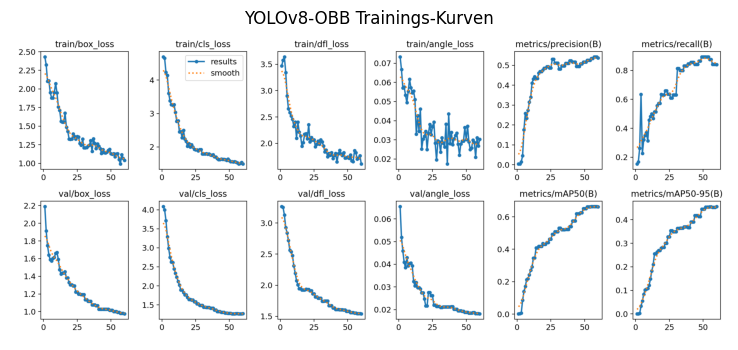

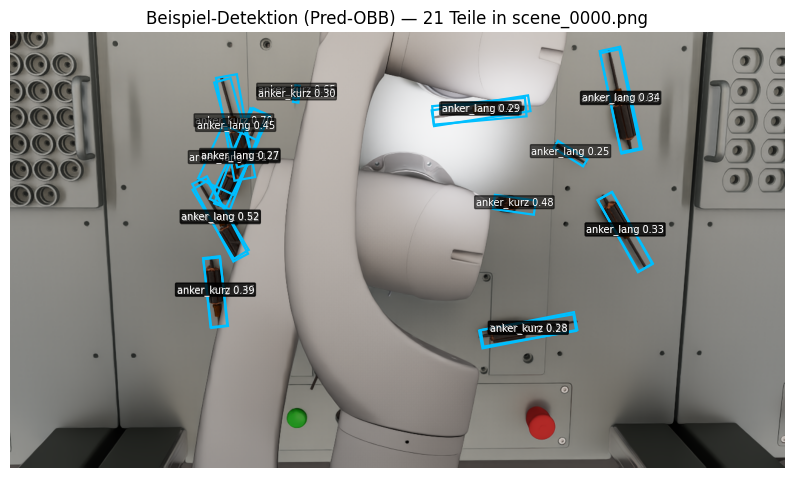

In [16]:
def show_detector(example_img=None):
    """Trainings-Kurven (detector.curves.png) + eine Pred-OBB-Beispiel-Detektion."""
    import matplotlib.pyplot as plt, numpy as np
    from PIL import Image
    from matplotlib.patches import Polygon
    mp = MODELS / "detector.metrics.json"
    if mp.exists():
        m = json.load(open(mp))
        print(f"Detektor: mAP50={m['map50']:.3f}  mAP50-95={m['map50_95']:.3f}  "
              f"classes={m['classes']}  ({m['epochs']} Epochen)")
    curves = MODELS / "detector.curves.png"
    if curves.exists():
        fig, ax = plt.subplots(figsize=(11, 4)); ax.imshow(np.asarray(Image.open(curves)))
        ax.axis("off"); ax.set_title("YOLOv8-OBB Trainings-Kurven"); plt.show()
    # Beispiel-Detektion (lokal, braucht ultralytics + ein Szenen-Bild)
    if example_img is None:
        cands = sorted((PROJECT / "input").glob("*.png"))
        example_img = cands[0] if cands else None
    if example_img is None or not (MODELS / "detector.pt").exists():
        print("keine Beispiel-Detektion (kein Bild bzw. detector.pt fehlt)."); return
    try:
        from ultralytics import YOLO
        r = YOLO(str(MODELS / "detector.pt")).predict(str(example_img), imgsz=960, conf=0.25, verbose=False)[0]
    except Exception as e:
        print(f"Beispiel-Detektion übersprungen ({e!r})."); return
    rgb = np.asarray(Image.open(example_img).convert("RGB"))
    fig, ax = plt.subplots(figsize=(10, 6)); ax.imshow(rgb)
    n = 0
    if r.obb is not None and len(r.obb):
        polys = r.obb.xyxyxyxy.cpu().numpy(); cls = r.obb.cls.cpu().numpy().astype(int)
        conf = r.obb.conf.cpu().numpy(); names = r.names; n = len(polys)
        for poly, c, cf in zip(polys, cls, conf):
            ax.add_patch(Polygon(poly, closed=True, fill=False, edgecolor="deepskyblue", lw=1.6))
            cx, cy = poly[:, 0].mean(), poly[:, 1].mean()
            ax.text(cx, cy, f"{names[int(c)]} {cf:.2f}", color="white", fontsize=7, ha="center",
                    bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.55))
    ax.set_title(f"Beispiel-Detektion (Pred-OBB) — {n} Teile in {example_img.name}"); ax.axis("off")
    plt.show()

show_detector()


## Zusammenfassung

Nach Durchlauf liegen vor:

* `training_data/faceset_<part>/` — die SDG-Renders (auf der Box; Beispiele lokal)
* `models/registry/<part>/faces_<part>.json` + `tmpl_Face<k>.png` — Face-Registry
* `training_data/snippets/<part>/<face_id>/*.png` + `manifest.json` — Trainings-Set
* `models/<part>.pt` (+ `<part>.metrics.json`) — trainierter Face-Classifier
  (für Multi-Face-Teile; 1-Face-Teile brauchen keinen)
* `training_data/detect/` (+ `detect.yaml`) — YOLOv8-OBB-Detektor-Dataset
* `models/detector.pt` (+ `detector.metrics.json`, `detector.curves.png`) —
  echt trainierter **OBB-Detektor** (anker_kurz/anker_lang, mAP50 ≈ 0.66)

Diese Artefakte konsumiert `infer.ipynb` / `e2e_infer.py`. Der Pipeline-Code dort
ist bewusst dupliziert/inline (Selbsterklärbarkeit, Weitergabe an Dritte).

**Stufen-Status (ehrlich):**
- Stufen 1-5 sind **echt durchgelaufen**: Facesets gerendert, Registries gebaut,
  Face-Classifier trainiert (Zahnrad val_acc 0.97, Buerstenhalter 1.0; Anker_*/
  Poltopf/Getriebe = trivialer 1-Klassen-Fall), Detektor trainiert (mAP50 ≈ 0.66).
- **Offen / dokumentiert (kein Stub):** Kamera-Intrinsics-Kalibrierung für
  metrisch exakte Backprojection (aktuell dokumentiertes Top-Down-Default-Modell);
  Detektor-Klassen wachsen mit gerenderten Szenen (aktuell anker_kurz/anker_lang).
